In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, recall_score
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
import shap

In [ ]:
df = pd.read_csv("credit_nasabah_data.csv")

# supaya ga scientific notation
np.set_printoptions(suppress=True)

# optional: biar ada koma dan 2 desimal
pd.options.display.float_format = '{:,.4f}'.format

In [3]:
list(df.columns)

['dt_closed',
 'dt_active',
 'wo_date',
 'no_biaya',
 'no_cif',
 'no_id_acc',
 'no_id_acc_prev',
 'no_biaya_prev',
 'dh',
 'wisma',
 'bcarea',
 'desa',
 'kel_kec',
 'kota_kab',
 'age_nasabah',
 'marital_status',
 'age_pasangan',
 'education_level',
 'totchild',
 'umur_dan_tanggungan',
 'residence_status',
 'jumlah_gesang_prev',
 'plafond_new',
 'plafond_old',
 'angsuran_new',
 'angsuran_old',
 'growth_angsuran_baru',
 'growth_plafond_baru',
 'sal_tabungan',
 'avg_bal_3mth',
 'freq_setor_3mth',
 'avg_amtsetor_3mth',
 'freq_tarik_3mth',
 'avg_amttarik_3mth',
 'avg_bal_6mth',
 'freq_setor_6mth',
 'avg_amtsetor_6mth',
 'freq_tarik_6mth',
 'avg_amttarik_6mth',
 'visit_count',
 'fl_col',
 'fl_ctx',
 'fl_x',
 'fl_30',
 'fl_everctx_mob3',
 'fl_everx_mob3',
 'fl_ever30_mob3',
 'fl_evercol_mob3',
 'fl_everctx_mob6',
 'fl_everx_mob6',
 'fl_ever30_mob6',
 'fl_evercoll_mob6',
 'visit_count_prev',
 'fl_col_prev',
 'fl_ctx_prev',
 'fl_x_prev',
 'fl_30_prev',
 'fl_everctx_mob3_prev',
 'fl_everx_mob3_p

In [4]:
#variabel yang di drop (tidak digunakan)
cols_model = [
        'fl_x',
        'fl_30',
        'fl_col',
        'fl_ctx', 
        'plafond_new',
        'plafond_old', 
        'angsuran_new',
        'desa', 
        'kel_kec',
        'angsuran_old', 
        'growth_angsuran_baru', 
        'growth_plafond_baru', 
        'sal_tabungan',
        'avg_bal_3mth', 
        'freq_setor_3mth', 
        'avg_amtsetor_3mth', 
        'freq_tarik_3mth', 
        'avg_amttarik_3mth', 
        'avg_bal_6mth', 
        'freq_setor_6mth', 
        'avg_amtsetor_6mth', 
        'freq_tarik_6mth', 
        'avg_amttarik_6mth', 
        'visit_count',
        'fl_everx_mob3', 
        'fl_everctx_mob3', 
        'fl_evercol_mob3', 
        'fl_ever30_mob3',
        'fl_everctx_mob6',
        'fl_everx_mob6', 
        'fl_evercoll_mob6', 
        'freq_id_mob3', 
        'freq_id_mob6', 
        'ever_id_mob3',
        'ever_id_mob6', 
        'visit_success_mob2', 
        'devcode', 
        'tenor', 
        'product', 
        'nama_siklus', 
        'previous_flag_dipercepat',
        'news_tetangga', 
        'had_debt', 
        'remarks1',
        'umur_dan_tanggungan', 
        'visit_success_mob5', 
        'prs_ptw_mob2', 
        'prs_ptw_mob5',
        'coll_ptw_mob2', 
        'coll_ptw_mob5', 
        'prs_telat_mob2', 
        'prs_telat_mob5', 
        'coll_telat_mob2', 
        'coll_telat_mob5', 
        'capacity_mpp',
        'dt_active', 
        'no_id_acc', 
        'wo_date',  
        'no_cif',
        'dt_closed', 
        'no_biaya_prev', 
        'total_visit_success_6m_prev',
        'no_id_acc_prev', 
        'total_prs_6m_prev', 
        'no_biaya',
        'jml_prs',
        'total_visit_success_6m',
        'flag_nyicil_collect',
        'product_prev'
    ]

In [5]:
df = df.copy()


df_features = df.fillna(0)

df_features = df_features.replace({
    True: 1,
    False: 0,
    'True': 1,
    'False': 0,
    'Y': 1,
    'N': 0,
    '0': 0,
    None: 0,
    'nan': 0,
    'NaN': 0
})

# mapping
df_features['previous_flag_dipercepat'] = df_features['previous_flag_dipercepat'].map({
    'Dipercepat': 1,
    'Tidak dipercepat': 0
})

df_features['previous_flag_dipercepat_prev'] = df_features['previous_flag_dipercepat_prev'].map({
    'Dipercepat': 1,
    'Tidak dipercepat': 0
})
df_features = pd.get_dummies(df_features, columns=['dh'], drop_first=True)

BINNING UNTUK VARIABEL PEMBIAYAAN SEBELUMNYA

       avg_bal_3mth_prev  avg_bal_6mth_prev  freq_setor_3mth_prev  \
count       950,863.0000       978,623.0000        1,008,692.0000   
mean        869,718.6079       865,532.5186                4.1842   
std         638,129.0653       629,548.6803                2.7916   
min               0.0000             0.0000                0.0000   
25%         500,000.0000       500,000.0000                2.0000   
50%         706,000.0000       705,600.0000                4.0000   
75%       1,052,625.0000     1,054,000.0000                7.0000   
max      55,017,777.7777    61,231,363.6363               32.0000   

       freq_setor_6mth_prev  avg_amtsetor_3mth_prev  avg_amtsetor_6mth_prev  \
count        1,008,692.0000            945,476.0000            974,824.0000   
mean                 8.0838            203,675.5669            148,395.7749   
std                  5.1145            276,954.7993            215,097.5364   
min                  0.0000                500.0000           

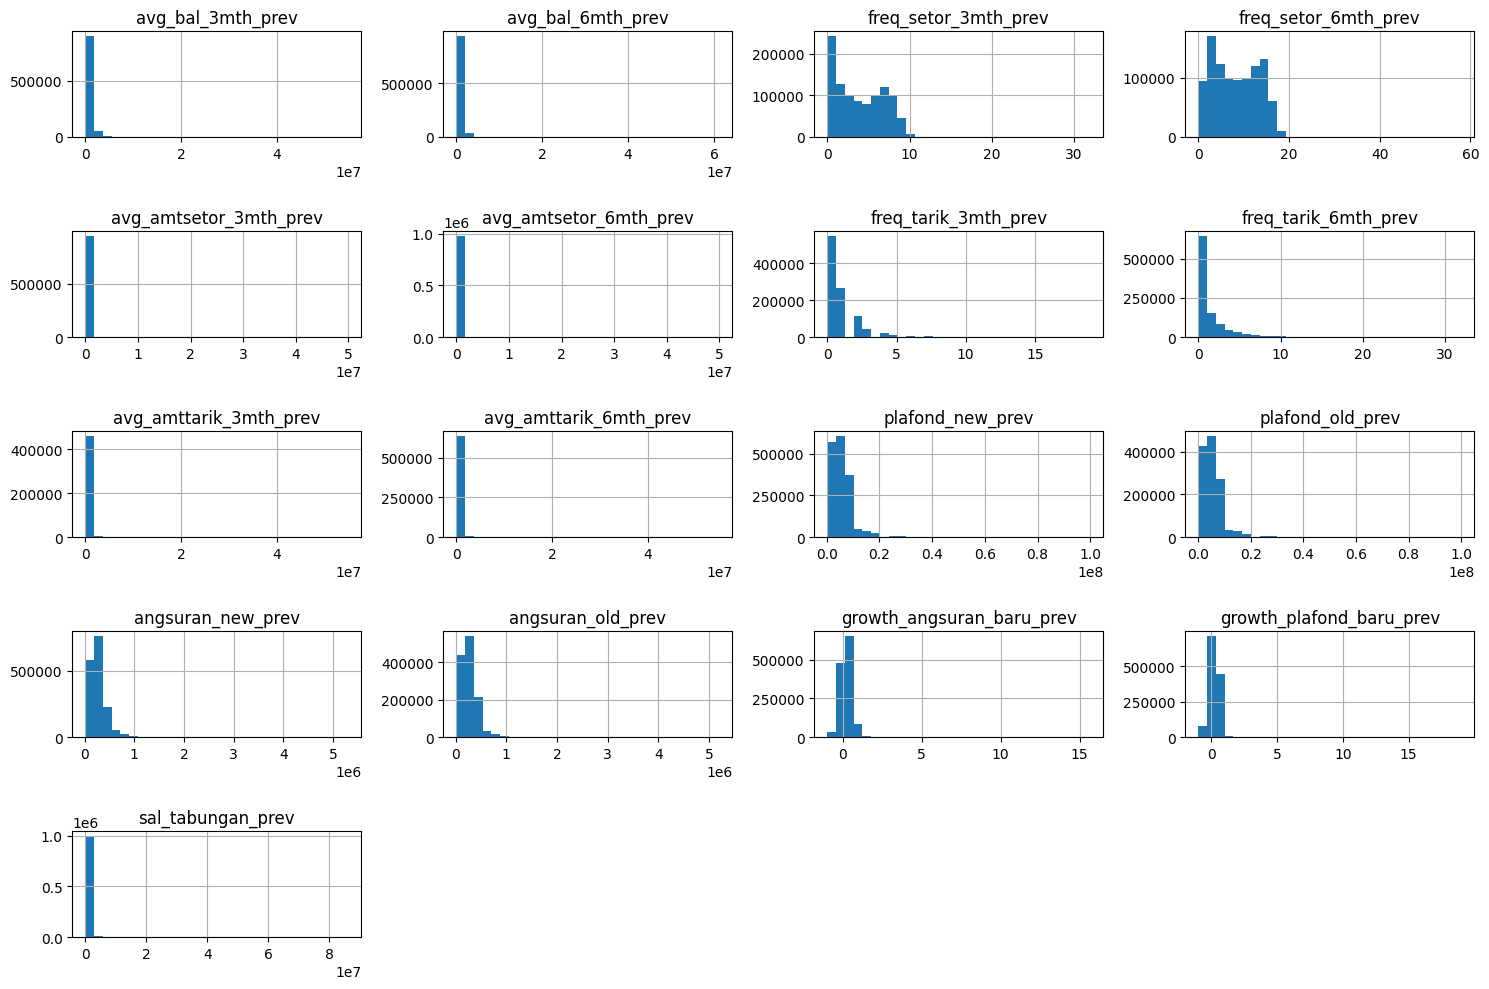

In [6]:
#count, mean, std, min, 25%, 50%, 75%, max dari variabel numerik
col_desc_prev = [
    'avg_bal_3mth_prev',
    'avg_bal_6mth_prev',
    'freq_setor_3mth_prev',
    'freq_setor_6mth_prev',
    'avg_amtsetor_3mth_prev',
    'avg_amtsetor_6mth_prev',
    'freq_tarik_3mth_prev',
    'freq_tarik_6mth_prev',
    'avg_amttarik_3mth_prev',
    'avg_amttarik_6mth_prev',
    'plafond_new_prev',
    'plafond_old_prev',
    'angsuran_new_prev',
    'angsuran_old_prev',
    'growth_angsuran_baru_prev',
    'growth_plafond_baru_prev',
    'sal_tabungan_prev'
]

print(df[col_desc_prev].describe())

# Visualization for EDA
df[col_desc_prev].hist(bins=30, figsize=(15,10))
plt.tight_layout()
plt.show()

In [7]:
for col in col_desc_prev:

    X = df_features[[col]]
    y = df_features['fl_ever30_mob6']

    tree = DecisionTreeClassifier(
        max_leaf_nodes=4,
        min_samples_leaf=5000
    )

    tree.fit(X, y)

    print(col)
    print(tree.tree_.threshold)

avg_bal_3mth_prev
[1021683.34375      -2.      1865516.6875       -2.      2149763.875
      -2.           -2.     ]
avg_bal_6mth_prev
[1021559.03125    300340.578125       -2.          81159.6640625
      -2.             -2.             -2.       ]
freq_setor_3mth_prev
[ 5.5  0.5 -2.  -2.   1.5 -2.  -2. ]
freq_setor_6mth_prev
[12.5  8.5 -2.   0.5 -2.  -2.  -2. ]
avg_amtsetor_3mth_prev
[181585.7109375    250.            -2.            -2.
 114950.            -2.            -2.       ]
avg_amtsetor_6mth_prev
[138218.25         500.            -2.            -2.
  69594.1171875     -2.            -2.       ]
freq_tarik_3mth_prev
[ 1.5 -2.   2.5 -2.   6.5 -2.  -2. ]
freq_tarik_6mth_prev
[ 3.5  1.5 -2.   0.5 -2.  -2.  -2. ]
avg_amttarik_3mth_prev
[101800.           -2.       381416.671875     -2.       406833.328125
     -2.           -2.      ]
avg_amttarik_6mth_prev
[117416.66796875     -2.         389416.671875       -2.
 403550.             -2.             -2.        ]
plafond_new_prev

In [8]:
#binning growth angsuran baru untuk melihat rata-rata fl_ever30_mob6 berdasarkan kelompok growth angsuran baru
bins_growth_angsuran_baru_prev = [-0.9750, -0.05365425, 0.23875, 0.94935897, 15.6667]
labels_growth_angsuran_baru_prev = ['1', '2', '3', '4']

df_features['growth_angsuran_baru_bin_prev'] = pd.cut(
    df_features['growth_angsuran_baru_prev'],
    bins=bins_growth_angsuran_baru_prev,
    labels=labels_growth_angsuran_baru_prev,
    include_lowest=True
)

summary_growth_angsuran_baru_prev = (
    df_features.groupby('growth_angsuran_baru_prev')
    ['fl_ever30_mob6']
    .agg(
            total_nasabah='count',
            jumlah_bad='sum',
            bad_rate='mean'
    )
    .reset_index()
)
print(summary_growth_angsuran_baru_prev)

      growth_angsuran_baru_prev  total_nasabah  jumlah_bad  bad_rate
0                       -0.9750              1           0    0.0000
1                       -0.9700              1           0    0.0000
2                       -0.9231              1           0    0.0000
3                       -0.9000              1           0    0.0000
4                       -0.8947              1           0    0.0000
...                         ...            ...         ...       ...
1189                     9.0000              2           0    0.0000
1190                     9.0160              1           0    0.0000
1191                    10.2500              1           0    0.0000
1192                    12.1250              1           0    0.0000
1193                    15.6667              1           0    0.0000

[1194 rows x 4 columns]


In [9]:
df_features['growth_plafond_baru_prev'].value_counts()

growth_plafond_baru_prev
0.0000     808185
0.6667     128333
0.3333     127768
0.5000     114828
1.0000      91986
            ...  
-0.5600         1
-0.4048         1
-0.2052         1
-0.0298         1
-0.3011         1
Name: count, Length: 676, dtype: int64

In [10]:
#binning freq setor 3 bulan untuk melihat rata-rata fl_ever30_mob6 berdasarkan kelompok freq setor 3 bulan
bins_growth_plafond_baru_prev = [-0.9850, -0.10096236, 0.46862745 , 1.36666667, 19.0000]
labels_growth_plafond_baru_prev = ['1', '2', '3', '4']

df_features['growth_plafond_baru_bin_prev'] = pd.cut(
    df_features['growth_plafond_baru_prev'],
    bins=bins_growth_plafond_baru_prev,
    labels=labels_growth_plafond_baru_prev,
    include_lowest=True
)

summary_growth_plafond_baru_prev = (
    df_features.groupby('growth_plafond_baru_prev')
    ['fl_ever30_mob6']
    .agg(
            total_nasabah='count',
            jumlah_bad='sum',
            bad_rate='mean'
    )
    .reset_index()
)
print(summary_growth_plafond_baru_prev)

     growth_plafond_baru_prev  total_nasabah  jumlah_bad  bad_rate
0                     -0.9850              1           0    0.0000
1                     -0.9242              1           0    0.0000
2                     -0.9200              1           0    0.0000
3                     -0.9143              1           0    0.0000
4                     -0.9032              1           0    0.0000
..                        ...            ...         ...       ...
671                   12.3333              1           0    0.0000
672                   14.0000              1           0    0.0000
673                   15.6667              1           0    0.0000
674                   16.5000              1           0    0.0000
675                   19.0000              1           0    0.0000

[676 rows x 4 columns]


In [11]:
#binning freq setor 3 bulan untuk melihat rata-rata fl_ever30_mob6 berdasarkan kelompok freq setor 3 bulan
bins_freq_setor_3mth_prev = [-1, 2, 6, 32]
labels_freq_setor_3mth_prev = ['0-1', '2-5', '+6']

df_features['freq_setor_3mth_bin_prev'] = pd.cut(
    df_features['freq_setor_3mth_prev'],
    bins=bins_freq_setor_3mth_prev,
    labels=labels_freq_setor_3mth_prev,
    include_lowest=True
)

summary_freq_setor_3mth_prev = (
    df_features.groupby('freq_setor_3mth_bin_prev')
    ['fl_ever30_mob6']
    .agg(
            total_nasabah='count',
            jumlah_bad='sum',
            bad_rate='mean'
    )
    .reset_index()
)
print(summary_freq_setor_3mth_prev)

  freq_setor_3mth_bin_prev  total_nasabah  jumlah_bad  bad_rate
0                      0-1        1135857       16243    0.0143
1                      2-5         362955        4943    0.0136
2                       +6         276045        3292    0.0119


In [12]:
#binning freq setor 3 bulan untuk melihat rata-rata fl_ever30_mob6 berdasarkan kelompok umur
bins_avg_bal_3mth_prev = [-1, 500000, 1421683, 2149763, 55017777]
labels_avg_bal_3mth_prev = ['0-499K', '500K-1.4M', '1.4M-2.1M', '55M+']

df_features['avg_bal_3mth_bin_prev'] = pd.cut(
    df_features['avg_bal_3mth_prev'],
    bins=bins_avg_bal_3mth_prev,
    labels=labels_avg_bal_3mth_prev,
    include_lowest=True
)

summary_avg_bal_3mth_prev = (
    df_features.groupby('avg_bal_3mth_bin_prev')
    ['fl_ever30_mob6']
       .agg(
            total_nasabah='count',
            jumlah_bad='sum',
            bad_rate='mean'
    )
    .reset_index()
)
print(summary_avg_bal_3mth_prev)

  avg_bal_3mth_bin_prev  total_nasabah  jumlah_bad  bad_rate
0                0-499K        1064248       14861    0.0140
1             500K-1.4M         595577        8087    0.0136
2             1.4M-2.1M          80524        1083    0.0134
3                  55M+          34507         447    0.0130


In [13]:
#binning freq setor 3 bulan untuk melihat rata-rata fl_ever30_mob6 berdasarkan kelompok umur
bins_avg_bal_6mth_prev = [-1, 81159, 2021559, 61231363]
labels_avg_bal_6mth_prev = ['0-81K', '81K-2.0M', '2.0M+']

df_features['avg_bal_6mth_bin_prev'] = pd.cut(
    df_features['avg_bal_6mth_prev'],
    bins=bins_avg_bal_6mth_prev,
    labels=labels_avg_bal_6mth_prev,
    include_lowest=True
)

summary_avg_bal_6mth_prev = (
    df_features.groupby('avg_bal_6mth_bin_prev')
    ['fl_ever30_mob6']
        .agg(
            total_nasabah='count',
            jumlah_bad='sum',
            bad_rate='mean'
    )
    .reset_index()
)
print(summary_avg_bal_6mth_prev)

  avg_bal_6mth_bin_prev  total_nasabah  jumlah_bad  bad_rate
0                 0-81K         796413       11154    0.0140
1              81K-2.0M         937284       12792    0.0136
2                 2.0M+          41159         532    0.0129


In [14]:
#binning freq setor 6 bulan untuk melihat rata-rata fl_ever30_mob6 berdasarkan kelompok freq setor 6 bulan
bins_freq_setor_6mth_prev = [-1, 8, 12, 58]
labels_freq_setor_6mth_prev = ['0-7', '8-11', '+12']

df_features['freq_setor_6mth_bin_prev'] = pd.cut(
    df_features['freq_setor_6mth_prev'],
    bins=bins_freq_setor_6mth_prev,
    labels=labels_freq_setor_6mth_prev,
    include_lowest=True
)

summary_freq_setor_6mth_prev = (
    df_features.groupby('freq_setor_6mth_bin_prev')
    ['fl_ever30_mob6']
    .agg(
            total_nasabah='count',
            jumlah_bad='sum',
            bad_rate='mean'
    )
    .reset_index()
)
print(summary_freq_setor_6mth_prev)

  freq_setor_6mth_bin_prev  total_nasabah  jumlah_bad  bad_rate
0                      0-7        1304499       18698    0.0143
1                     8-11         205204        2765    0.0135
2                      +12         265154        3015    0.0114


In [15]:
#binning avg amtsetor 3 bulan untuk melihat rata-rata fl_ever30_mob6 berdasarkan kelompok avg amtsetor 3 bulan
bins_avg_amtsetor_3mth_prev = [-1, 114950, 181585, 50000000]
labels_avg_amtsetor_3mth_prev = ['0-114.9K', '114.9K-181.5K', '181.5K+']

df_features['avg_amtsetor_3mth_bin_prev'] = pd.cut(
    df_features['avg_amtsetor_3mth_prev'],
    bins=bins_avg_amtsetor_3mth_prev,
    labels=labels_avg_amtsetor_3mth_prev,
    include_lowest=True
)

summary_avg_amtsetor_3mth_prev = (
    df_features.groupby('avg_amtsetor_3mth_bin_prev')
    ['fl_ever30_mob6']
    .agg(
            total_nasabah='count',
            jumlah_bad='sum',
            bad_rate='mean'
    )
    .reset_index()
)
print(summary_avg_amtsetor_3mth_prev)

  avg_amtsetor_3mth_bin_prev  total_nasabah  jumlah_bad  bad_rate
0                   0-114.9K        1291055       16821    0.0130
1              114.9K-181.5K         137549        1986    0.0144
2                    181.5K+         346253        5671    0.0164


In [16]:
#binning avg amtsetor 6 bulan untuk melihat rata-rata fl_ever30_mob6 berdasarkan kelompok avg amtsetor 6 bulan
bins_avg_amtsetor_6mth_prev = [0,114950, 181585, 1000000, 50000000]
labels_avg_amtsetor_6mth_prev = ['0-114.9K', '114.9K-181.5K', '181.5K-1M', '1M+']

df_features['avg_amtsetor_6mth_bin_prev'] = pd.cut(
    df_features['avg_amtsetor_6mth_prev'],
    bins=bins_avg_amtsetor_6mth_prev,
    labels=labels_avg_amtsetor_6mth_prev,
    include_lowest=True
)

summary_avg_amtsetor_6mth_prev = (
    df_features.groupby('avg_amtsetor_6mth_bin_prev')
    ['fl_ever30_mob6']
       .agg(
            total_nasabah='count',
            jumlah_bad='sum',
            bad_rate='mean'
    )
    .reset_index()
)
print(summary_avg_amtsetor_6mth_prev)

  avg_amtsetor_6mth_bin_prev  total_nasabah  jumlah_bad  bad_rate
0                   0-114.9K        1365565       17625    0.0129
1              114.9K-181.5K         143471        2207    0.0154
2                  181.5K-1M         260838        4552    0.0175
3                        1M+           4983          94    0.0189


In [17]:
#binning freq tarik 3 bulan untuk melihat rata-rata fl_ever30_mob6 berdasarkan kelompok freq tarik 3 bulan
bins_freq_tarik_3mth_prev = [-1, 3, 7, 19]
labels_freq_tarik_3mth_prev = ['0-2', '3-6', '7+']

df_features['freq_tarik_3mth_bin_prev'] = pd.cut(
    df_features['freq_tarik_3mth_prev'],
    bins=bins_freq_tarik_3mth_prev,
    labels=labels_freq_tarik_3mth_prev,
    include_lowest=True
)

summary_freq_tarik_3mth_prev = (
    df_features.groupby('freq_tarik_3mth_bin_prev')
    ['fl_ever30_mob6']
       .agg(
            total_nasabah='count',
            jumlah_bad='sum',
            bad_rate='mean'
    )
    .reset_index()
)
print(summary_freq_tarik_3mth_prev)

  freq_tarik_3mth_bin_prev  total_nasabah  jumlah_bad  bad_rate
0                      0-2        1733672       23676    0.0137
1                      3-6          38842         741    0.0191
2                       7+           2343          61    0.0260


In [18]:
#binning freq tarik 6 bulan untuk melihat rata-rata fl_ever30_mob6 berdasarkan kelompok freq tarik 6 bulan
bins_freq_tarik_6mth_prev = [-1, 2, 4, 32]
labels_freq_tarik_6mth_prev = ['0-1', '2-3', '4+']

df_features['freq_tarik_6mth_bin_prev'] = pd.cut(
    df_features['freq_tarik_6mth_prev'],
    bins=bins_freq_tarik_6mth_prev,
    labels=labels_freq_tarik_6mth_prev,
    include_lowest=True
)

summary_freq_tarik_6mth_prev = (
    df_features.groupby('freq_tarik_6mth_bin_prev')
    ['fl_ever30_mob6']
       .agg(
            total_nasabah='count',
            jumlah_bad='sum',
            bad_rate='mean'
    )
    .reset_index()
)
print(summary_freq_tarik_6mth_prev)

  freq_tarik_6mth_bin_prev  total_nasabah  jumlah_bad  bad_rate
0                      0-1        1557791       20323    0.0130
1                      2-3         126936        2235    0.0176
2                       4+          90130        1920    0.0213


In [19]:
#binning avg amt tarik 6 bulan untuk melihat rata-rata fl_ever30_mob6 berdasarkan kelompok avg amt tarik 6 bulan
bins_avg_amttarik_6mth_prev = [-1, 200000, 55000000]
labels_avg_amttarik_6mth_prev = ['0-200K', '200K+']

df_features['avg_amttarik_6mth_bin_prev'] = pd.cut(
    df_features['avg_amttarik_6mth_prev'],
    bins=bins_avg_amttarik_6mth_prev,
    labels=labels_avg_amttarik_6mth_prev,
    include_lowest=True
)

summary_avg_amttarik_6mth_prev = (
    df_features.groupby('avg_amttarik_6mth_bin_prev')
    ['fl_ever30_mob6']
       .agg(
            total_nasabah='count',
            jumlah_bad='sum',
            bad_rate='mean'
    )
    .reset_index()
)
print(summary_avg_amttarik_6mth_prev)

  avg_amttarik_6mth_bin_prev  total_nasabah  jumlah_bad  bad_rate
0                     0-200K        1284927       17100    0.0133
1                      200K+         489930        7378    0.0151


In [20]:
#binning avg amt tarik 3 bulan untuk melihat rata-rata fl_ever30_mob6 berdasarkan kelompok avg amt tarik 3 bulan
bins_avg_amttarik_3mth_prev = [-1, 200000, 55000000]
labels_avg_amttarik_3mth_prev = ['0-200K', '200K+']

df_features['avg_amttarik_3mth_bin_prev'] = pd.cut(
    df_features['avg_amttarik_3mth_prev'],
    bins=bins_avg_amttarik_3mth_prev,
    labels=labels_avg_amttarik_3mth_prev,
    include_lowest=True
)

summary_avg_amttarik_3mth_prev = (
    df_features.groupby('avg_amttarik_3mth_bin_prev')
    ['fl_ever30_mob6']
       .agg(
            total_nasabah='count',
            jumlah_bad='sum',
            bad_rate='mean'
    )
    .reset_index()
)
print(summary_avg_amttarik_3mth_prev)

  avg_amttarik_3mth_bin_prev  total_nasabah  jumlah_bad  bad_rate
0                     0-200K        1422184       19185    0.0135
1                      200K+         352673        5293    0.0150


In [21]:
bin_cols_prev = ['freq_setor_3mth_bin_prev',
            'avg_bal_3mth_bin_prev',
            'avg_bal_6mth_bin_prev',
            'freq_setor_6mth_bin_prev',
            'avg_amtsetor_3mth_bin_prev',
            'avg_amtsetor_6mth_bin_prev',
            'freq_tarik_3mth_bin_prev',
            'freq_tarik_6mth_bin_prev',
            'avg_amttarik_6mth_bin_prev',
            'avg_amttarik_3mth_bin_prev',
            'growth_plafond_baru_bin_prev',
            'growth_angsuran_baru_bin_prev'
            ]
df_features = df_features.dropna(subset=bin_cols_prev)
df_features[bin_cols_prev].isna().sum()

freq_setor_3mth_bin_prev         0
avg_bal_3mth_bin_prev            0
avg_bal_6mth_bin_prev            0
freq_setor_6mth_bin_prev         0
avg_amtsetor_3mth_bin_prev       0
avg_amtsetor_6mth_bin_prev       0
freq_tarik_3mth_bin_prev         0
freq_tarik_6mth_bin_prev         0
avg_amttarik_6mth_bin_prev       0
avg_amttarik_3mth_bin_prev       0
growth_plafond_baru_bin_prev     0
growth_angsuran_baru_bin_prev    0
dtype: int64

In [22]:
for col in bin_cols_prev:

    rank_table = (
        df_features.groupby(col)['fl_ever30_mob6']
        .agg(
            total_nasabah='count',
            jumlah_bad='sum',
            bad_rate='mean'
        )
        .reset_index()
    )

    # rank 1 = paling baik
    rank_table = rank_table.sort_values(
        by='bad_rate',
        ascending=True
    )

    rank_table['rank'] = range(
        1,
        len(rank_table)+1
    )

    # urutan kolom
    rank_table = rank_table[
        [col, 'total_nasabah', 'jumlah_bad', 'bad_rate', 'rank']
    ]

    mapping = dict(
        zip(
            rank_table[col],
            rank_table['rank']
        )
    )

    # bikin kolom ranking baru
    df_features[col.replace('_bin', '_rank')] = (
        df_features[col].map(mapping)
    )

    df_features[col.replace('_bin', '_rank')] = (
        df_features[col.replace('_bin', '_rank')]
        .astype(int)
    )

    print(f'\n===== {col} =====')
    print(rank_table)


===== freq_setor_3mth_bin_prev =====
  freq_setor_3mth_bin_prev  total_nasabah  jumlah_bad  bad_rate  rank
2                       +6         276045        3292    0.0119     1
1                      2-5         362953        4943    0.0136     2
0                      0-1        1135857       16243    0.0143     3

===== avg_bal_3mth_bin_prev =====
  avg_bal_3mth_bin_prev  total_nasabah  jumlah_bad  bad_rate  rank
3                  55M+          34506         447    0.0130     1
2             1.4M-2.1M          80524        1083    0.0134     2
1             500K-1.4M         595577        8087    0.0136     3
0                0-499K        1064248       14861    0.0140     4

===== avg_bal_6mth_bin_prev =====
  avg_bal_6mth_bin_prev  total_nasabah  jumlah_bad  bad_rate  rank
2                 2.0M+          41158         532    0.0129     1
1              81K-2.0M         937284       12792    0.0136     2
0                 0-81K         796413       11154    0.0140     3

===== fr

output_file = "ranking_bins_prev_jumlah.xlsx"

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:

    for col in bin_cols_prev:

        rank_table = (
            df_features.groupby(col)['fl_ever30_mob6']
            .agg(
                total_nasabah='count',
                jumlah_bad='sum',
                bad_rate='mean'
            )
            .reset_index()
        )

        # urut berdasarkan bad rate
        rank_table = rank_table.sort_values(
            by='bad_rate',
            ascending=True
        )

        # bikin ranking
        rank_table['rank'] = range(
            1,
            len(rank_table)+1
        )

        # urutan kolom
        rank_table = rank_table[
            [col, 'total_nasabah', 'jumlah_bad', 'bad_rate', 'rank']
        ]

        # mapping rank
        mapping = dict(
            zip(
                rank_table[col],
                rank_table['rank']
            )
        )

        # bikin kolom rank baru
        df_features[col.replace('_bin', '_rank')] = (
            df_features[col].map(mapping)
        )

        df_features[col.replace('_bin', '_rank')] = (
            df_features[col.replace('_bin', '_rank')]
            .astype(int)
        )

        # simpan ke excel
        sheet_name = col[:31]

        rank_table.to_excel(
            writer,
            sheet_name=sheet_name,
            index=False
        )

        print(f'\n===== {col} =====')
        print(rank_table)

print(f"File berhasil disimpan ke: {output_file}")

BINNING UNTUK VARIABEL PEMBIAYAAN TERBARU

         age_nasabah   age_pasangan       totchild     avg_bal_3mth  \
count 1,774,857.0000 1,537,478.0000 1,663,791.0000   1,769,312.0000   
mean         44.4309        48.3239         2.0799     916,353.2276   
std          10.2315        12.2649         1.4792     665,020.7150   
min          19.0000       -24.0000         0.0000           0.0000   
25%          37.0000        40.0000         1.0000     517,500.0000   
50%          44.0000        48.0000         2.0000     758,555.5555   
75%          52.0000        56.0000         3.0000   1,112,500.0000   
max         126.0000       126.0000         7.0000 197,048,750.0000   

          avg_bal_6mth  freq_setor_3mth  freq_setor_6mth  avg_amtsetor_3mth  \
count   1,774,116.0000   1,774,857.0000   1,774,857.0000     1,767,912.0000   
mean      899,765.6787           5.0259           9.1039       257,455.7366   
std       657,171.5337           2.8450           5.0580       495,548.6861   
min             0.0000           0.0000     

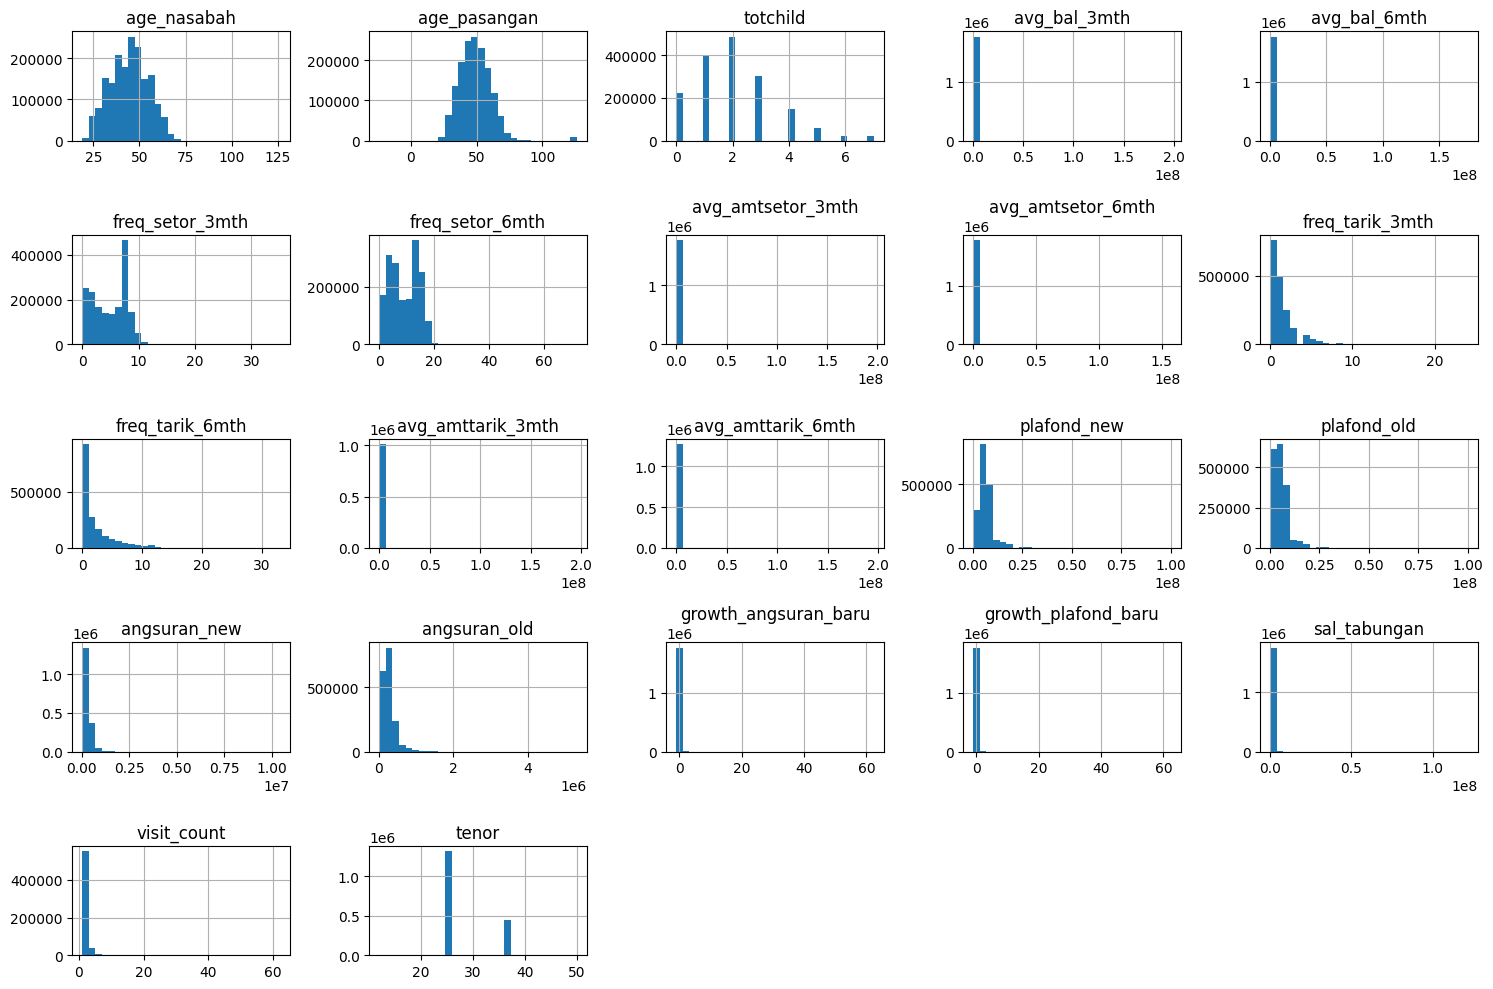

In [23]:
#count, mean, std, min, 25%, 50%, 75%, max dari variabel numerik
col_desc = [
    'age_nasabah',
    'age_pasangan',
    'totchild',
    'avg_bal_3mth',
    'avg_bal_6mth',
    'freq_setor_3mth',
    'freq_setor_6mth',
    'avg_amtsetor_3mth',
    'avg_amtsetor_6mth',
    'freq_tarik_3mth',
    'freq_tarik_6mth',
    'avg_amttarik_3mth',
    'avg_amttarik_6mth',
    'plafond_new',
    'plafond_old',
    'angsuran_new',
    'angsuran_old',
    'growth_angsuran_baru',
    'growth_plafond_baru',
    'sal_tabungan',
    'visit_count',
    'tenor'
]

print(df[col_desc].describe())

# Visualization for EDA
df[col_desc].hist(bins=30, figsize=(15,10))
plt.tight_layout()
plt.show()

In [ ]:
#membersihkan outlier karena ada beberapa nilai yang tidak masuk akal seperti 2000 anak atau umur 100 tahun, sehingga perlu dibatasi
if 'totchild' in df_features.columns:
    df_features['totchild'] = df_features['totchild'].apply(lambda x: 7 if x > 7 else x)

#karena umur nasabah dalam sop adalah maksimal 60 tahun
if 'age_nasabah' in df_features.columns:
    df_features['age_nasabah'] = df_features['age_nasabah'].apply(lambda x: 60 if x > 60 else x)

if 'age_pasangan' in df_features.columns:
    df_features['age_pasangan'] = df_features['age_pasangan'].apply(lambda x: 19 if x < 19 else (70 if x > 70 else x))

In [25]:
if 'age_pasangan' in df_features.columns: df_features.loc[df_features['age_pasangan'] < 0, 'age_pasangan'] = 0

In [26]:
for col in col_desc:

    X = df_features[[col]]
    y = df_features['fl_ever30_mob6']

    tree = DecisionTreeClassifier(
        max_leaf_nodes=5,
        min_samples_leaf=5000
    )

    tree.fit(X, y)

    print(col)
    print(tree.tree_.threshold)

age_nasabah
[40.5 29.5 46.5 24.5 -2.  -2.  -2.  -2.  -2. ]
age_pasangan
[ 43.5  35.5  47.5  -2.   -2.   -2.  103.5  -2.   -2. ]
totchild
[ 2.5  1.5  3.5 -2.  -2.  -2.   6.5 -2.  -2. ]
avg_bal_3mth
[299881.71875  57424.0625  499949.53125     -2.          -2.
     -2.      194227.          -2.          -2.     ]
avg_bal_6mth
[307972.796875 199043.046875 498929.359375     -2.           -2.
 409499.265625     -2.           -2.           -2.      ]
freq_setor_3mth
[ 6.5  2.5 -2.   1.5  5.5 -2.  -2.  -2.  -2. ]
freq_setor_6mth
[ 9.5  3.5 11.5 -2.  -2.  -2.   8.5 -2.  -2. ]
avg_amtsetor_3mth
[124319.25       77866.0703125 499414.28125   155105.5546875
     -2.            -2.            -2.            -2.
     -2.       ]
avg_amtsetor_6mth
[116496.5         77870.83203125 153696.15625        -2.
     -2.             -2.         156404.546875       -2.
     -2.        ]
freq_tarik_3mth
[ 3.5  2.5  4.5  1.5 -2.  -2.  -2.  -2.  -2. ]
freq_tarik_6mth
[ 3.5  2.5  8.5 -2.  -2.   4.5 -2.  -2.  -2. ]


In [27]:
# binning umur pasangan

df_features['age_pasangan_bins'] = np.where(

    # 0 dan NaN digabung
    (df_features['age_pasangan'] == np.nan) |
    (df_features['age_pasangan'] <= 17),
    'Tidak Punya Pasangan',

    pd.cut(
        df_features['age_pasangan'],
        bins=[18,25,35,45,71,126],
        labels=['18-25','26-35','36-45','46-71','>72'],
        include_lowest=True
    ).astype(str)
)

# summary risk
summary_age_pasangan = (
    df_features.groupby('age_pasangan_bins')
    ['fl_ever30_mob6']
    .agg(
        total_nasabah='count',
        jumlah_bad='sum',
        bad_rate='mean'
    )
    .reset_index()
)

print(summary_age_pasangan)

      age_pasangan_bins  total_nasabah  jumlah_bad  bad_rate
0                 18-25          10205         253    0.0248
1                 26-35         199357        3679    0.0185
2                 36-45         442291        6557    0.0148
3                 46-71         856427        9267    0.0108
4                   >72          29109         373    0.0128
5  Tidak Punya Pasangan         237466        4349    0.0183


In [28]:
np.sort(df_features['age_nasabah'].unique())

array([ 19,  20,  21,  22,  23,  24,  25,  26,  27,  28,  29,  30,  31,
        32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,  44,
        45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,  57,
        58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  70,
        71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,
        84,  85,  86,  88,  90,  91,  96, 104, 126])

In [29]:
#binning umur nasabah untuk melihat rata-rata fl_ever30_mob6 berdasarkan kelompok umur
age_bins = [18, 27, 35, 43, 51, 59, 126]
labels = ['19-27', '28-35', '36-43', '44-51', '52-60', '>60']
df_features['age_bins'] = pd.cut(
    df_features['age_nasabah'],
    bins=age_bins,
    labels=labels,
    include_lowest=True
)

summary_age = (
    df_features.groupby('age_bins')
    ['fl_ever30_mob6']
    .agg(
            total_nasabah='count',
            jumlah_bad='sum',
            bad_rate='mean'
    )
    .reset_index()
)
print(summary_age)

  age_bins  total_nasabah  jumlah_bad  bad_rate
0    19-27          88156        1870    0.0212
1    28-35         296833        5256    0.0177
2    36-43         437817        6530    0.0149
3    44-51         478731        5721    0.0120
4    52-60         338397        3681    0.0109
5      >60         134921        1420    0.0105


In [30]:
#binning freq setor 3 bulan untuk melihat rata-rata fl_ever30_mob6 berdasarkan kelompok freq setor 3 bulan
bins_freq_setor_3mth = [-1, 2, 5, 7, 35]
labels_freq_setor_3mth = ['0-1', '2-4', '5-6', '7+']

df_features['freq_setor_3mth_bin'] = pd.cut(
    df_features['freq_setor_3mth'],
    bins=bins_freq_setor_3mth,
    labels=labels_freq_setor_3mth,
    include_lowest=True
)

summary_freq_setor_3mth = (
    df_features.groupby('freq_setor_3mth_bin')
    ['fl_ever30_mob6']
    .agg(
            total_nasabah='count',
            jumlah_bad='sum',
            bad_rate='mean'
    )
    .reset_index()
)
print(summary_freq_setor_3mth)

  freq_setor_3mth_bin  total_nasabah  jumlah_bad  bad_rate
0                 0-1         488578        5623    0.0115
1                 2-4         443032       11590    0.0262
2                 5-6         405761        4927    0.0121
3                  7+         437484        2338    0.0053


In [31]:
#binning totchild bulan untuk melihat rata-rata fl_ever30_mob6 berdasarkan kelompok totchild
bins_totchild = [-1, 1, 2, 3, 8]
labels_totchild = ['0-1', '2-3', '4-7', '8+']

df_features['totchild_bin'] = pd.cut(
    df_features['totchild'],
    bins=bins_totchild,
    labels=labels_totchild,
    include_lowest=True
)

summary_totchild = (
    df_features.groupby('totchild_bin')
    ['fl_ever30_mob6']
    .agg(
            total_nasabah='count',
            jumlah_bad='sum',
            bad_rate='mean'
    )
    .reset_index()
)
print(summary_totchild)

  totchild_bin  total_nasabah  jumlah_bad  bad_rate
0          0-1         732598       11156    0.0152
1          2-3         488348        6797    0.0139
2          4-7         302249        3781    0.0125
3           8+         251660        2744    0.0109


In [32]:
#binning freq setor 3 bulan untuk melihat rata-rata fl_ever30_mob6 berdasarkan kelompok umur
bins_avg_bal_3mth = [-1, 299881.71875, 499949.53125, 197048750]
labels_avg_bal_3mth = ['1', '2', '3']

df_features['avg_bal_3mth_bin'] = pd.cut(
    df_features['avg_bal_3mth'],
    bins=bins_avg_bal_3mth,
    labels=labels_avg_bal_3mth,
    include_lowest=True
)

summary_avg_bal_3mth = (
    df_features.groupby('avg_bal_3mth_bin')
    ['fl_ever30_mob6']
    .agg(
            total_nasabah='count',
            jumlah_bad='sum',
            bad_rate='mean'
    )
    .reset_index()
)
print(summary_avg_bal_3mth)

  avg_bal_3mth_bin  total_nasabah  jumlah_bad  bad_rate
0                1          60022        4782    0.0797
1                2         325867        7162    0.0220
2                3        1388966       12534    0.0090


In [33]:
#binning freq setor 3 bulan untuk melihat rata-rata fl_ever30_mob6 berdasarkan kelompok umur
bins_avg_bal_6mth = [-1, 199043.046875, 307972.796875, 498929.359375, 175432222]
labels_avg_bal_6mth = ['1', '2', '3', '4']

df_features['avg_bal_6mth_bin'] = pd.cut(
    df_features['avg_bal_6mth'],
    bins=bins_avg_bal_6mth,
    labels=labels_avg_bal_6mth,
    include_lowest=True
)

summary_avg_bal_6mth = (
    df_features.groupby('avg_bal_6mth_bin')
    ['fl_ever30_mob6']
    .agg(
            total_nasabah='count',
            jumlah_bad='sum',
            bad_rate='mean'
    )
    .reset_index()
)
print(summary_avg_bal_6mth)

  avg_bal_6mth_bin  total_nasabah  jumlah_bad  bad_rate
0                1          18851        2631    0.1396
1                2          74412        5090    0.0684
2                3         319882        7269    0.0227
3                4        1361709        9488    0.0070


In [34]:
#binning freq setor 6 bulan untuk melihat rata-rata fl_ever30_mob6 berdasarkan kelompok freq setor 6 bulan
bins_freq_setor_6mth = [-1, 6, 14, 72]
labels_freq_setor_6mth = ['1', '2', '3']

df_features['freq_setor_6mth_bin'] = pd.cut(
    df_features['freq_setor_6mth'],
    bins=bins_freq_setor_6mth,
    labels=labels_freq_setor_6mth,
    include_lowest=True
)

summary_freq_setor_6mth = (
    df_features.groupby('freq_setor_6mth_bin')
    ['fl_ever30_mob6']
    .agg(
            total_nasabah='count',
            jumlah_bad='sum',
            bad_rate='mean'
    )
    .reset_index()
)
print(summary_freq_setor_6mth)

  freq_setor_6mth_bin  total_nasabah  jumlah_bad  bad_rate
0                   1         680641       16326    0.0240
1                   2         755922        7771    0.0103
2                   3         338292         381    0.0011


In [35]:
#binning avg amtsetor 3 bulan untuk melihat rata-rata fl_ever30_mob6 berdasarkan kelompok avg amtsetor 3 bulan
bins_avg_amtsetor_3mth = [-1, 77866, 199414, 196182500]
labels_avg_amtsetor_3mth = ['1', '2', '3']

df_features['avg_amtsetor_3mth_bin'] = pd.cut(
    df_features['avg_amtsetor_3mth'],
    bins=bins_avg_amtsetor_3mth,
    labels=labels_avg_amtsetor_3mth,
    include_lowest=True
)

summary_avg_amtsetor_3mth = (
    df_features.groupby('avg_amtsetor_3mth_bin')
    ['fl_ever30_mob6']
    .agg(
            total_nasabah='count',
            jumlah_bad='sum',
            bad_rate='mean'
    )
    .reset_index()
)
print(summary_avg_amtsetor_3mth)

  avg_amtsetor_3mth_bin  total_nasabah  jumlah_bad  bad_rate
0                     1         420082        1814    0.0043
1                     2         599844        8515    0.0142
2                     3         754929       14149    0.0187


In [36]:
#binning avg amtsetor 6 bulan untuk melihat rata-rata fl_ever30_mob6 berdasarkan kelompok avg amtsetor 6 bulan
bins_avg_amtsetor_6mth = [-1, 77870.83203125, 116496.5, 153696.15625, 157046001]
labels_avg_amtsetor_6mth = ['1', '2', '3', '4']

df_features['avg_amtsetor_6mth_bin'] = pd.cut(
    df_features['avg_amtsetor_6mth'],
    bins=bins_avg_amtsetor_6mth,
    labels=labels_avg_amtsetor_6mth,
    include_lowest=True
)

summary_avg_amtsetor_6mth = (
    df_features.groupby('avg_amtsetor_6mth_bin')
    ['fl_ever30_mob6']
    .agg(
            total_nasabah='count',
            jumlah_bad='sum',
            bad_rate='mean'
    )
    .reset_index()
)
print(summary_avg_amtsetor_6mth)

  avg_amtsetor_6mth_bin  total_nasabah  jumlah_bad  bad_rate
0                     1         597331        1771    0.0030
1                     2         274132        2778    0.0101
2                     3         185451        3188    0.0172
3                     4         717941       16741    0.0233


In [37]:
#binning freq tarik 3 bulan untuk melihat rata-rata fl_ever30_mob6 berdasarkan kelompok freq tarik 3 bulan
bins_freq_tarik_3mth = [-1, 5, 10, 23]
labels_freq_tarik_3mth = ['1', '2', '3']

df_features['freq_tarik_3mth_bin'] = pd.cut(
    df_features['freq_tarik_3mth'],
    bins=bins_freq_tarik_3mth,
    labels=labels_freq_tarik_3mth,
    include_lowest=True
)

summary_freq_tarik_3mth = (
    df_features.groupby('freq_tarik_3mth_bin')
    ['fl_ever30_mob6']
    .agg(
            total_nasabah='count',
            jumlah_bad='sum',
            bad_rate='mean'
    )
    .reset_index()
)
print(summary_freq_tarik_3mth)

  freq_tarik_3mth_bin  total_nasabah  jumlah_bad  bad_rate
0                   1        1724082       19207    0.0111
1                   2          48139        4904    0.1019
2                   3           2633         366    0.1390


In [38]:
#binning freq tarik 6 bulan untuk melihat rata-rata fl_ever30_mob6 berdasarkan kelompok freq tarik 6 bulan
bins_freq_tarik_6mth = [-1, 1, 2, 3, 4, 34]
labels_freq_tarik_6mth = ['1', '2', '3', '4', '5']

df_features['freq_tarik_6mth_bin'] = pd.cut(
    df_features['freq_tarik_6mth'],
    bins=bins_freq_tarik_6mth,
    labels=labels_freq_tarik_6mth,
    include_lowest=True
)

summary_freq_tarik_6mth = (
    df_features.groupby('freq_tarik_6mth_bin')
    ['fl_ever30_mob6']
    .agg(
            total_nasabah='count',
            jumlah_bad='sum',
            bad_rate='mean'
    )
    .reset_index()
)
print(summary_freq_tarik_6mth)

  freq_tarik_6mth_bin  total_nasabah  jumlah_bad  bad_rate
0                   1         926954         824    0.0009
1                   2         274332        1639    0.0060
2                   3         165234        3515    0.0213
3                   4         109180        4487    0.0411
4                   5         299155       14013    0.0468


In [39]:
#binning avg amt tarik 6 bulan untuk melihat rata-rata fl_ever30_mob6 berdasarkan kelompok avg amt tarik 6 bulan
bins_avg_amttarik_6mth = [0, 100000, 150000, 195682500]
labels_avg_amttarik_6mth = ['1', '2', '3']

df_features['avg_amttarik_6mth_bin'] = pd.cut(
    df_features['avg_amttarik_6mth'],
    bins=bins_avg_amttarik_6mth,
    labels=labels_avg_amttarik_6mth,
    include_lowest=True
)

summary_avg_amttarik_6mth = (
    df_features.groupby('avg_amttarik_6mth_bin')
    ['fl_ever30_mob6']
    .agg(
            total_nasabah='count',
            jumlah_bad='sum',
            bad_rate='mean'
    )
    .reset_index()
)
print(summary_avg_amttarik_6mth)

  avg_amttarik_6mth_bin  total_nasabah  jumlah_bad  bad_rate
0                     1         523077         375    0.0007
1                     2          93554        1630    0.0174
2                     3        1158224       22473    0.0194


In [40]:
#binning avg amt tarik 3 bulan untuk melihat rata-rata fl_ever30_mob6 berdasarkan kelompok avg amt tarik 6 bulan
bins_avg_amttarik_3mth = [-1, 80000, 120000, 195682500]
labels_avg_amttarik_3mth = ['1', '2', '3']

df_features['avg_amttarik_3mth_bin'] = pd.cut(
    df_features['avg_amttarik_3mth'],
    bins=bins_avg_amttarik_3mth,
    labels=labels_avg_amttarik_3mth,
    include_lowest=True
)

summary_avg_amttarik_3mth = (
    df_features.groupby('avg_amttarik_3mth_bin')
    ['fl_ever30_mob6']
    .agg(
            total_nasabah='count',
            jumlah_bad='sum',
            bad_rate='mean'
    )
    .reset_index()
)
print(summary_avg_amttarik_3mth)

  avg_amttarik_3mth_bin  total_nasabah  jumlah_bad  bad_rate
0                     1         771548        1015    0.0013
1                     2          59053         757    0.0128
2                     3         944254       22706    0.0240


In [41]:
bin_cols = ['age_bins',
            'age_pasangan_bins',
            'freq_setor_3mth_bin',
            'totchild_bin',
            'avg_bal_3mth_bin',
            'avg_bal_6mth_bin',
            'freq_setor_6mth_bin',
            'avg_amtsetor_3mth_bin',
            'avg_amtsetor_6mth_bin',
            'freq_tarik_3mth_bin',
            'freq_tarik_6mth_bin',
            'avg_amttarik_6mth_bin',
            'avg_amttarik_3mth_bin'
]
df_features[bin_cols].isna().sum()

age_bins                 0
age_pasangan_bins        0
freq_setor_3mth_bin      0
totchild_bin             0
avg_bal_3mth_bin         0
avg_bal_6mth_bin         1
freq_setor_6mth_bin      0
avg_amtsetor_3mth_bin    0
avg_amtsetor_6mth_bin    0
freq_tarik_3mth_bin      1
freq_tarik_6mth_bin      0
avg_amttarik_6mth_bin    0
avg_amttarik_3mth_bin    0
dtype: int64

In [42]:
df_features = df_features.dropna(subset=bin_cols)

In [43]:
df_features[bin_cols].isna().sum()

age_bins                 0
age_pasangan_bins        0
freq_setor_3mth_bin      0
totchild_bin             0
avg_bal_3mth_bin         0
avg_bal_6mth_bin         0
freq_setor_6mth_bin      0
avg_amtsetor_3mth_bin    0
avg_amtsetor_6mth_bin    0
freq_tarik_3mth_bin      0
freq_tarik_6mth_bin      0
avg_amttarik_6mth_bin    0
avg_amttarik_3mth_bin    0
dtype: int64

In [44]:
bin_cols = ['age_bins',
            'age_pasangan_bins',
            'freq_setor_3mth_bin',
            'totchild_bin',
            'avg_bal_3mth_bin',
            'avg_bal_6mth_bin',
            'freq_setor_6mth_bin',
            'avg_amtsetor_3mth_bin',
            'avg_amtsetor_6mth_bin',
            'freq_tarik_3mth_bin',
            'freq_tarik_6mth_bin',
            'avg_amttarik_6mth_bin',
            'avg_amttarik_3mth_bin'
]

for col in bin_cols:

    rank_table = (
        df_features.groupby(col)['fl_ever30_mob6']
        .agg(
            total_nasabah='count',
            jumlah_bad='sum',
            bad_rate='mean'
    )
    .reset_index()
    )

    # rank 1 = paling baik
    rank_table = rank_table.sort_values(
        by='bad_rate',
        ascending=True
    )

    rank_table['rank'] = range(
        1,
        len(rank_table)+1
    )

    mapping = dict(
        zip(
            rank_table[col],
            rank_table['rank']
        )
    )

    # bikin kolom ranking baru
    df_features[col.replace('_bin', '_rank')] = (
        df_features[col].map(mapping)
    )

    df_features[col.replace('_bin', '_rank')] = df_features[col.replace('_bin', '_rank')].astype(int)

    print(f'\n===== {col} =====')
    print(rank_table)


===== age_bins =====
  age_bins  total_nasabah  jumlah_bad  bad_rate  rank
5      >60         134921        1420    0.0105     1
4    52-60         338397        3681    0.0109     2
3    44-51         478731        5721    0.0120     3
2    36-43         437815        6529    0.0149     4
1    28-35         296833        5256    0.0177     5
0    19-27          88156        1870    0.0212     6

===== age_pasangan_bins =====
      age_pasangan_bins  total_nasabah  jumlah_bad  bad_rate  rank
3                 46-71         856425        9266    0.0108     1
4                   >72          29109         373    0.0128     2
2                 36-45         442291        6557    0.0148     3
5  Tidak Punya Pasangan         237466        4349    0.0183     4
1                 26-35         199357        3679    0.0185     5
0                 18-25          10205         253    0.0248     6

===== freq_setor_3mth_bin =====
  freq_setor_3mth_bin  total_nasabah  jumlah_bad  bad_rate  rank
3 

output_file = "ranking_bins_jumlah.xlsx"

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:

    for col in bin_cols:

        rank_table = (
            df_features.groupby(col)['fl_ever30_mob6']
            .agg(
                total_nasabah='count',
                jumlah_bad='sum',
                bad_rate='mean'
            )
            .reset_index()
        )

        # urut berdasarkan bad rate
        rank_table = rank_table.sort_values(
            by='bad_rate',
            ascending=True
        )

        # bikin ranking
        rank_table['rank'] = range(
            1,
            len(rank_table)+1
        )

        # urutan kolom
        rank_table = rank_table[
            [col, 'total_nasabah', 'jumlah_bad', 'bad_rate', 'rank']
        ]

        # mapping rank
        mapping = dict(
            zip(
                rank_table[col],
                rank_table['rank']
            )
        )

        # bikin kolom rank baru
        df_features[col.replace('_bin', '_rank')] = (
            df_features[col].map(mapping)
        )

        df_features[col.replace('_bin', '_rank')] = (
            df_features[col.replace('_bin', '_rank')]
            .astype(int)
        )

        # simpan ke excel
        sheet_name = col[:31]

        rank_table.to_excel(
            writer,
            sheet_name=sheet_name,
            index=False
        )

        print(f'\n===== {col} =====')
        print(rank_table)

print(f"File berhasil disimpan ke: {output_file}")

In [45]:
dh_groups = {}

# DH1 (baseline)
dh_groups['DH1'] = df_features[
    (df_features['dh_DH 2'] == 0) &
    (df_features['dh_DH 3'] == 0) &
    (df_features['dh_DH 4'] == 0) &
    (df_features['dh_DH 5'] == 0)
]

# DH2–DH5
for i in range(2, 6):
    col = f'dh_DH {i}'
    dh_groups[f'DH{i}'] = df_features[df_features[col] == 1]

In [46]:
def train_model(df_subset, name, shap_flag=False):

    Y_model = df_subset['fl_ever30_mob6']
    id_biaya = df_subset['no_biaya']

    cat_features = [
        'wisma', 'education_level',
        'residence_status', 'remarks1_prev', 'nama_siklus_prev', 'devcode_prev', 'kota_kab',
        'marital_status',
        'bcarea'
    ]

    
    drop_cols_model = [
        'fl_ever30_mob6',
        'flag_nyicil_collect',   
        'age_bins',
        'age_nasabah',
        'age_pasangan', 
        'age_pasangan_bins',
        'freq_setor_3mth_bin',
        'totchild',
        'totchild_bin',
        'growth_angsuran_baru_prev',
        'growth_plafond_baru_prev',
        'growth_angsuran_baru_bin_prev',
        'growth_plafond_baru_bin_prev',
        'avg_bal_3mth_bin',
        'avg_bal_6mth_bin',
        'freq_setor_6mth_bin',
        'avg_amtsetor_3mth_bin',
        'avg_amtsetor_6mth_bin',
        'freq_tarik_3mth_bin',
        'freq_tarik_6mth_bin',
        'avg_amttarik_6mth_bin',
        'avg_amttarik_3mth_bin',
        'freq_setor_3mth_bin_prev',
        'avg_bal_3mth_bin_prev',
        'avg_bal_6mth_bin_prev',
        'freq_setor_6mth_bin_prev',
        'avg_amtsetor_3mth_bin_prev',
        'avg_amtsetor_6mth_bin_prev',
        'freq_tarik_3mth_bin_prev',
        'freq_tarik_6mth_bin_prev',
        'avg_amttarik_3mth_bin_prev',
        'avg_amttarik_6mth_bin_prev',
        'avg_bal_3mth_rank_prev',
        'freq_setor_3mth_prev', 
        'avg_amtsetor_3mth_prev',
        'freq_tarik_3mth_prev', 
        'avg_amttarik_3mth_prev', 
        'avg_bal_6mth_prev',
        'freq_setor_6mth_prev', 
        'avg_amtsetor_6mth_prev',
        'freq_tarik_6mth_prev', 
        'avg_amttarik_6mth_prev', 
        'freq_id_mob3_prev',
        'freq_id_mob6_prev',
        'freq_setor_3mth_rank',
        'avg_bal_3mth_rank',
        'avg_bal_6mth_rank',
        'freq_setor_6mth_rank',
        'avg_amtsetor_3mth_rank',
        'avg_amtsetor_6mth_rank',
        'freq_tarik_3mth_rank',
        'freq_tarik_6mth_rank',
        'avg_amttarik_6mth_rank',
        'avg_amttarik_3mth_rank'
    ] + cols_model

    X_model = df_subset.drop(columns=drop_cols_model, errors='ignore')


    X_train, X_test, Y_train, Y_test, id_train, id_test = train_test_split(
        X_model, Y_model, id_biaya, test_size=0.3, random_state=42
    )

    
    model = CatBoostClassifier(
    iterations=2000,
    depth=10,
    learning_rate=0.03,
    scale_pos_weight=25,
    random_seed=42,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=100
    )

    
    model.fit(
        X_train,
        Y_train,
        cat_features=cat_features,
        eval_set=(X_test, Y_test),
        use_best_model=True,
        early_stopping_rounds=100
    )

    y_pred = model.predict(X_test)
    y_pred = np.array(y_pred).astype(int).flatten()

    y_proba = model.predict_proba(X_test)[:, 1]

    result = X_test.copy()

    result['no_biaya'] = id_test.values
    result['actual'] = Y_test.values
    result['pred'] = y_pred
    result['prob_bad'] = y_proba

    result = result.sort_values(
        by='prob_bad',
        ascending=False
    )

    print(f"\n===== {name} =====")
    print(classification_report(Y_test, y_pred))

    cm = confusion_matrix(Y_test, y_pred)
    
    cm_df = pd.DataFrame(
    cm,
    index=['Actual Good','Actual Bad'],
    columns=['Pred Good','Pred Bad']
    )

    print(cm_df)

    roc_auc = roc_auc_score(Y_test, y_proba)
    print(f"ROC AUC Score: {roc_auc}")

    # default value
    importance = None
    top_features = None

    if shap_flag:

        explainer = shap.TreeExplainer(model)
        shap_values = explainer(X_test)

        shap.summary_plot(shap_values, X_test)
        plt.show()

        importance = (
            pd.DataFrame({
                'feature': X_test.columns,
                'mean_abs_shap': np.abs(shap_values.values).mean(axis=0)
            })
            .sort_values('mean_abs_shap', ascending=False)
        )

        top_features = (
            importance['feature']
            .head(3)
            .tolist()
        )

        print("\nTop Features:")
        print(importance.head(3))

    return model, result, importance, top_features

In [48]:
for dh_name in all_result:

    result = all_result[dh_name]['result']

    bad = result['actual'].sum()
    total = len(result)
    good = total - bad

    print(
        f"{dh_name} | Total={total:} | Good={good:} | Bad={bad:} | BR={bad/total:.2%}"
    )

DH1 | Total=171239 | Good=168477 | Bad=2762 | BR=1.61%
DH2 | Total=79199 | Good=77755 | Bad=1444 | BR=1.82%
DH3 | Total=115401 | Good=113858 | Bad=1543 | BR=1.34%
DH4 | Total=69428 | Good=68789 | Bad=639 | BR=0.92%
DH5 | Total=97191 | Good=96363 | Bad=828 | BR=0.85%


In [62]:
result.groupby(
    pd.qcut(result['prob_bad'], 10)
)['actual'].mean()

prob_bad
(0.0334, 0.0937]   0.0026
(0.0937, 0.109]    0.0033
(0.109, 0.123]     0.0032
(0.123, 0.137]     0.0047
(0.137, 0.152]     0.0065
(0.152, 0.17]      0.0066
(0.17, 0.193]      0.0084
(0.193, 0.221]     0.0103
(0.221, 0.266]     0.0152
(0.266, 0.516]     0.0244
Name: actual, dtype: float64

In [63]:
top10 = result[
    result['prob_bad'] >= result['prob_bad'].quantile(0.9)
]

print("Bad di Top 10% :", top10['actual'].sum())
print("Total Bad :", result['actual'].sum())

print(
    top10['actual'].sum()
    /
    result['actual'].sum()
)

Bad di Top 10% : 237
Total Bad : 828
0.286231884057971


In [60]:
tree_rows = []

def recursive_segment(
    df,
    features,
    depth=0,
    min_n=30,
    path=""
):
    global tree_rows

    if len(features) == 0:
        return

    feature = features[0]

    summary = (
        df.groupby(feature)
        .agg(
            total_nasabah=('actual','count'),
            total_bad=('actual','sum'),
            avg_prob_bad=('prob_bad','mean')
        )
        .reset_index()
    )

    summary['bad_rate'] = (
        summary['total_bad']
        / summary['total_nasabah']
    )

    summary = summary.sort_values(
        'bad_rate',
        ascending=False
    )

    for _, row in summary.iterrows():

        if row['total_nasabah'] < min_n:
            continue

        current_path = (
            f"{path} -> {feature}={row[feature]}"
            if path
            else f"{feature}={row[feature]}"
        )

        tree_rows.append({
            'depth': depth,
            'path': current_path,
            'feature': feature,
            'value': row[feature],
            'total_nasabah': row['total_nasabah'],
            'total_bad': row['total_bad'],
            'bad_rate': row['bad_rate'],
            'avg_prob_bad': row['avg_prob_bad']
        })

        subset = df[df[feature] == row[feature]]

        recursive_segment(
            subset,
            features[1:],
            depth + 1,
            min_n,
            current_path
        )

In [51]:
from openpyxl import Workbook

In [61]:
with pd.ExcelWriter("tree_segmentation_dh.xlsx", engine="openpyxl") as writer:

    for dh_name in all_result:

        tree_rows = []  # reset tiap DH

        recursive_segment(
            all_result[dh_name]['result'],
            all_result[dh_name]['top_features'],
            min_n=30
        )

        tree_df = pd.DataFrame(tree_rows)

        tree_df.to_excel(
            writer,
            sheet_name=dh_name[:31],
            index=False
        )

In [53]:
for dh_name in all_result:
    print(f"\n{dh_name}")
    print(all_result[dh_name]['top_features'])


DH1
['nama_siklus_prev', 'evercol_6bef_closed', 'age_ranks']

DH2
['nama_siklus_prev', 'evercol_6bef_closed', 'age_pasangan_ranks']

DH3
['evercol_6bef_closed', 'age_pasangan_ranks', 'remarks1_prev']

DH4
['evercol_6bef_closed', 'nama_siklus_prev', 'age_pasangan_ranks']

DH5
['evercol_6bef_closed', 'bcarea', 'kota_kab']
